In [1]:
import pandas as pd
import numpy as np


In [2]:
#uploading dataset
data=pd.read_csv("D:/sql/SampleSuperstore.csv")


In [3]:
data.head(5)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [110]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub-Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


In [5]:
data.describe()


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
data.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [7]:
data.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(17)

In [9]:
data.shape

(9994, 13)

In [13]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9989    False
9990    False
9991    False
9992    False
9993    False
Length: 9994, dtype: bool

In [14]:
duplicates = data[data.duplicated()]
duplicates.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
3406,Standard Class,Home Office,United States,Columbus,Ohio,43229,East,Furniture,Chairs,281.372,2,0.3,-12.0588
3670,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.368,2,0.2,3.6288
4117,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Paper,19.440,3,0.0,9.3312
4553,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,12.840,3,0.0,5.7780


In [15]:
duplicates.shape

(17, 13)

In [16]:
#DATA CLEANING

data=data.drop_duplicates()


In [17]:
data.duplicated().sum()


np.int64(0)

In [18]:
data.shape

(9977, 13)

In [39]:
#Key performnace imdcators
total_sales = data["Sales"].sum()
total_sales
#we can answer questions like the total sales and revenue generated by the company...

np.float64(2296195.5903)

In [40]:
total_profit=data["Profit"].sum()
total_profit

# how much profit compnay gained

np.float64(286241.42260000005)

In [41]:
total_quantity = data["Quantity"].sum()
total_quantity

np.int64(37820)

In [42]:
avg_sales = data["Sales"].mean()
avg_sales

np.float64(230.14890150345792)

In [43]:
#profit margin
profit_margin = (  (total_profit / total_sales ) * 100 )
profit_margin

np.float64(12.46589897695093)

In [46]:
print("totalSales : ",total_sales)
print("totalprofit : ",total_profit)
print("totalQuantity : ",total_quantity)
print("averageSales : ",avg_sales)
print("profitMargin : ",profit_margin)

totalSales :  2296195.5903
totalprofit :  286241.42260000005
totalQuantity :  37820
averageSales :  230.14890150345792
profitMargin :  12.46589897695093


In [54]:
sales_by_region = data.groupby("Region")["Sales"].sum().sort_values(ascending=True)

sales_by_region

Region
South      391721.9050
Central    500782.8528
East       678435.1960
West       725255.6365
Name: Sales, dtype: float64

In [55]:
profit_by_region = data.groupby("Region")["Profit"].sum().sort_values(ascending=True)
profit_by_region

Region
Central     39655.8752
South       46749.4303
East        91506.3092
West       108329.8079
Name: Profit, dtype: float64

In [56]:
#Central sells more than South

#But South earns more profit than Central

In [58]:
region_analysis = data.groupby("Region").agg({
    "Sales":"sum",
    "Profit":"sum"
})

region_analysis["Profit_Margin"] = (
    region_analysis["Profit"]
    /
    region_analysis["Sales"]
) * 100

region_analysis

,Sales,Profit,Profit_Margin
Region,,,
Central,500782.8528,39655.8752,7.918777
East,678435.1960,91506.3092,13.487848
South,391721.9050,46749.4303,11.934342
West,725255.6365,108329.8079,14.936776


In [63]:
region_analysis["Profit_Margin"].max()

#highest profit margin generated by which region and how much ...West

np.float64(14.936775730939114)

In [69]:
sales_by_category = data.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sales_by_category

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64

In [70]:
profit_by_category = data.groupby("Category")["Profit"].sum().sort_values(ascending=False)
profit_by_category

Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64

In [71]:
category_margin_profit = data.groupby("Category").agg({"Sales":"sum","Profit":"sum"})
category_margin_profit

,Sales,Profit
Category,,
Furniture,741306.3133,18421.8137
Office Supplies,718735.2440,122364.6608
Technology,836154.0330,145454.9481


In [73]:
category_margin_profit["Profit_Margin"] = (
    category_margin_profit["Profit"]
    /
  category_margin_profit["Sales"]
) * 100

category_margin_profit

,Sales,Profit,Profit_Margin
Category,,,
Furniture,741306.3133,18421.8137,2.485047
Office Supplies,718735.2440,122364.6608,17.024998
Technology,836154.0330,145454.9481,17.395712


In [74]:
print(sales_by_category)
print(profit_by_category)
print(category_margin_profit)

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64
Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64
                       Sales       Profit  Profit_Margin
Category                                                
Furniture        741306.3133   18421.8137       2.485047
Office Supplies  718735.2440  122364.6608      17.024998
Technology       836154.0330  145454.9481      17.395712


In [75]:
#Furniture generates strong revenue but extremely low profitability. 
#This suggests heavy discounting, higher operational costs, or low-margin products. 
#Management should investigate pricing strategy and product mix within the Furniture category

In [76]:
#sub_category analysis

In [83]:
#saleby sub category 
sales_by_sub_category = data.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
sales_by_sub_category

Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91683.0240
Paper           78224.1420
Supplies        46673.5380
Art             27107.0320
Envelopes       16476.4020
Labels          12444.9120
Fasteners        3024.2800
Name: Sales, dtype: float64

In [78]:
profit_by_sub_category = data.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)
profit_by_sub_category

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          33944.2395
Binders        30228.0003
Chairs         26567.1278
Storage        21278.8264
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Art             6524.6118
Labels          5526.3820
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [79]:
#top 10 sales -- which category
sales_by_sub_category.head(10)

Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

In [80]:
#least 5 sales --which category
sales_by_sub_category.tail(5)

Sub-Category
Supplies     46673.538
Art          27107.032
Envelopes    16476.402
Labels       12444.912
Fasteners     3024.280
Name: Sales, dtype: float64

In [81]:
#least 10 profit ---which category
profit_by_sub_category.tail(10)

Sub-Category
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Art             6524.6118
Labels          5526.3820
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [82]:
#highest profit by --which category
profit_by_sub_category.head(1)

Sub-Category
Copiers    55617.8249
Name: Profit, dtype: float64

In [84]:
#Tables generate very high revenue  but actually lose money.
#Tables generate very high revenue
#but actually lose money.

#Possible reasons:

#Heavy discounts
#High shipping costs
#Low margins
#Pricing problems

#bookcases losing money ---find!
#Sales = 114,880
#Profit = -3,473

In [90]:
#product based analysi top 10 sales or profits
print("top 10 sales products:\n ",sales_by_sub_category.head(10))

print("\n top 10 pritable products \n:",profit_by_sub_category.head(10))


top 10 sales products:
  Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

 top 10 pritable products 
: Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          33944.2395
Binders        30228.0003
Chairs         26567.1278
Storage        21278.8264
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Name: Profit, dtype: float64


In [91]:
#Phones = Best Product 

#Sales  = $330K
#Profit = $44.5K

#Copiers = Hidden Gold Mine--should invest in copiers
#Sales  = $149K
#Profit = $55.6K

#Tables = Business Problem ---selling a lot -> Losing money here
#Sales = $206K
#Profit = -$17.7K

#note :
#Phones and Copiers are the strongest-performing product segments. 
#Tables and Bookcases require immediate review due to negative profitability. 
#Despite strong revenue generation, the Furniture category contributes very little profit, indicating potential pricing or discount issues.

In [97]:
#finding answers why it happening 

#ROOT CAUSE ANALYSIS {RCA}

discount_analysis = (
    data.groupby("Sub-Category").agg({
    "Discount":"mean","Profit":"sum","Sales":"sum"  }).sort_values(by="Discount",ascending=False) )


print(discount_analysis)

              Discount      Profit        Sales
Sub-Category                                   
Binders       0.372011  30228.0003  203409.1690
Machines      0.306087   3384.7569  189238.6310
Tables        0.261285 -17725.4811  206965.5320
Bookcases     0.211140  -3472.5560  114879.9963
Chairs        0.170244  26567.1278  327777.7610
Appliances    0.166524  18138.0054  107532.1610
Copiers       0.161765  55617.8249  149528.0300
Phones        0.154556  44515.7306  330007.0540
Furnishings   0.138494  13052.7230   91683.0240
Fasteners     0.082028    949.5182    3024.2800
Envelopes     0.080315   6964.1767   16476.4020
Accessories   0.078452  41936.6357  167380.3180
Supplies      0.076842  -1189.0995   46673.5380
Art           0.074969   6524.6118   27107.0320
Paper         0.074908  33944.2395   78224.1420
Storage       0.074704  21278.8264  223843.6080
Labels        0.068871   5526.3820   12444.9120


In [98]:
furniture_data = data[
    data["Category"] == "Furniture"
]
furniture_data.groupby("Sub-Category")[["Sales","Profit","Discount"]].mean()

,Sales,Profit,Discount
Sub-Category,,,
Bookcases,503.859633,-15.230509,0.211140
Chairs,532.971969,43.198582,0.170244
Furnishings,95.902745,13.653476,0.138494
Tables,648.794771,-55.565771,0.261285


In [99]:
#Analysis indicates a strong relationship between higher discount rates and reduced profitability. 
#The Tables and Bookcases sub-categories receive some of the highest discounts in the portfolio and are currently generating negative profits.#
#Pricing and discount policies for these products should be reviewed

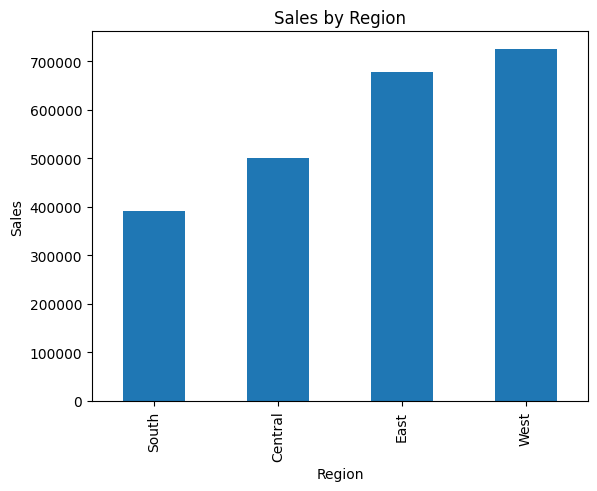

In [100]:
import matplotlib.pyplot as plt

sales_by_region.plot(kind="bar")

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

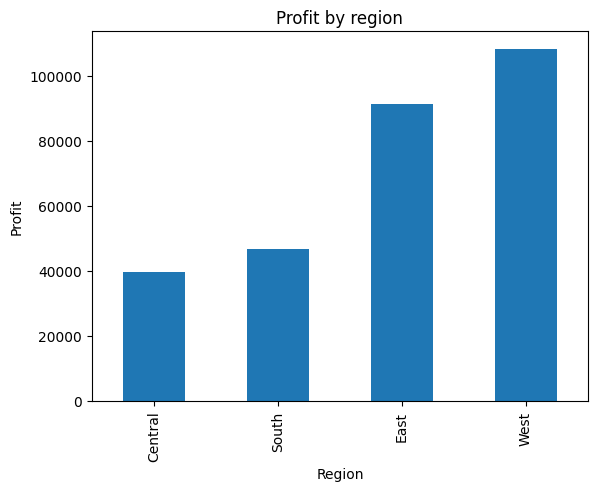

In [107]:
profit_by_region.plot(kind="bar")

plt.title("Profit by region")
plt.ylabel("Profit")
plt.show()

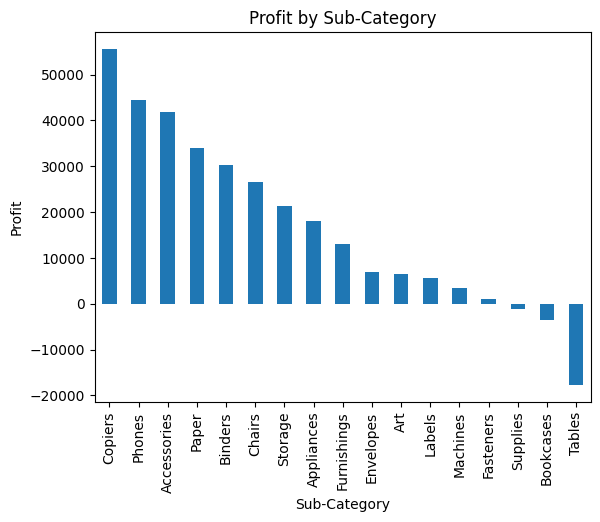

In [108]:
profit_by_sub_category.plot(kind="bar",)

plt.title("Profit by Sub-Category")
plt.ylabel("Profit")

plt.show()

In [111]:
#customer segment analysis

segment_analysis = data.groupby("Segment").agg({
    "Sales":"sum",
    "Profit":"sum"
})

print(segment_analysis)

                    Sales       Profit
Segment                               
Consumer     1.160833e+06  134007.4413
Corporate    7.060701e+05   91954.9798
Home Office  4.292927e+05   60279.0015


In [112]:
#stae wise
state_profit = (
    data.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(state_profit.head(10))

State
California    76330.7891
New York      74015.4622
Washington    33368.2375
Michigan      24428.0903
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


In [113]:
data[["Sales","Profit","Discount","Quantity"]].corr()

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479067,-0.028311,0.200722
Profit,0.479067,1.000000,-0.219662,0.066211
Discount,-0.028311,-0.219662,1.000000,0.008678
Quantity,0.200722,0.066211,0.008678,1.000000


In [1]:
import os
print(os.getcwd())


C:\Users\Lenovo
